In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
df=pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [4]:
df.isnull().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0
Address,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
if 'Address' in df.columns:
  df.drop(['Address'],axis=1,inplace=True)

In [7]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [8]:
pd.set_option('display.float_format','{:.2f}'.format)

In [9]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81
4,59982.20,5.04,7.84,4.23,26354.11,630943.49


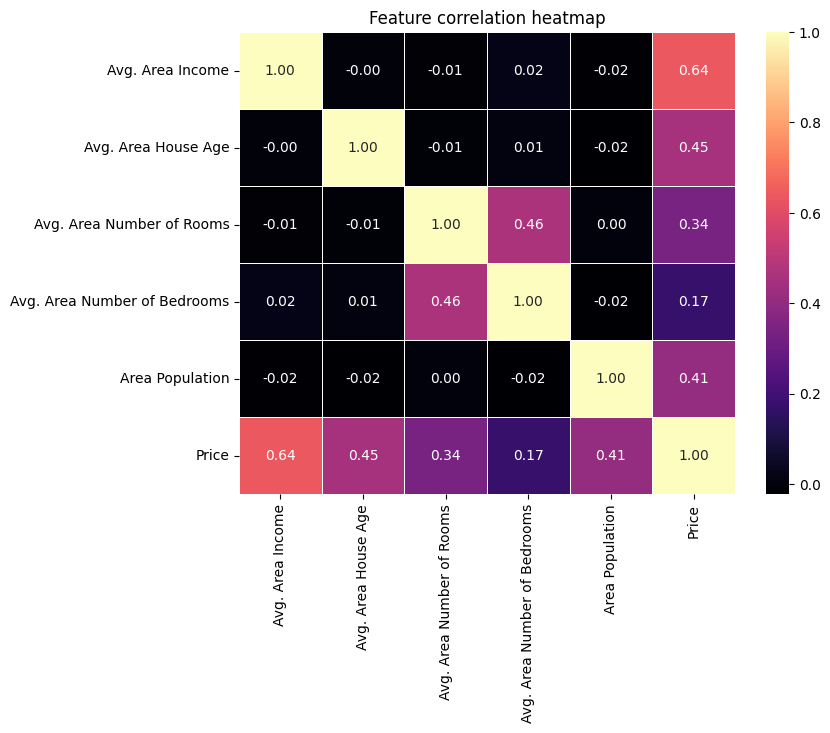

In [10]:
plt.figure(figsize=(8,6))
corr_matrix=df.corr()
sns.heatmap(corr_matrix,cmap='magma',annot=True,fmt=".2f",linewidth=0.5)
plt.title("Feature correlation heatmap")
plt.show()

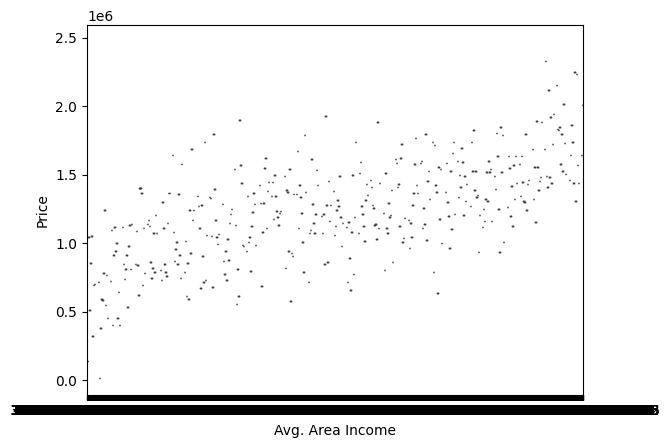

In [11]:
sns.boxplot(x=df["Avg. Area Income"],y=df["Price"])
plt.show()

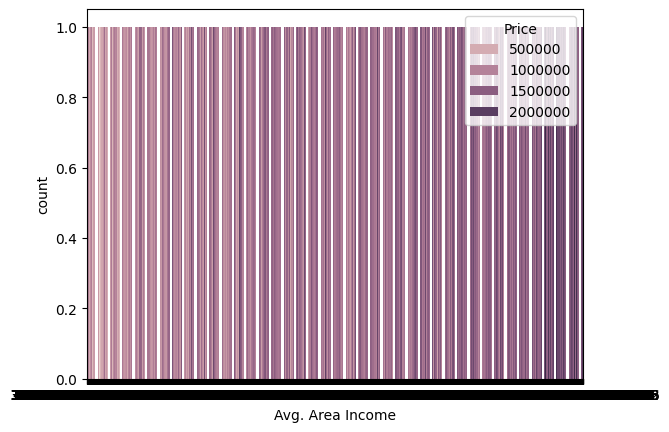

In [12]:
sns.countplot(x="Avg. Area Income",hue="Price", data=df)
plt.show()

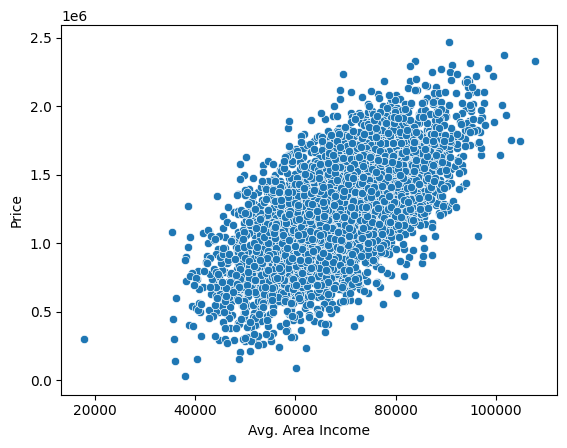

In [13]:
sns.scatterplot(x="Avg. Area Income",y="Price",data=df)
plt.show()

Simple Linear Regression

In [14]:
x=df[['Avg. Area Income']]
y=df['Price']

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
slr_model=LinearRegression()
slr_model.fit(x_train,y_train)

LinearRegression()

In [17]:
y_pred=slr_model.predict(x_test)

In [18]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
print("Simple linear regression result")
print("-----------------------------")
print("MAE: ",mean_absolute_error(y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 score: ",r2_score(y_test,y_pred))

Simple linear regression result
-----------------------------
MAE:  216826.35309989064
MSE:  74194887058.66
RMSE:  272387.38417676394
R2 score:  0.39694865192619766


In [19]:
print("Intercept: ",slr_model.intercept_)
print("Slope: ",slr_model.coef_[0])

Intercept:  -225053.70287170145
Slope:  21.208906292657513


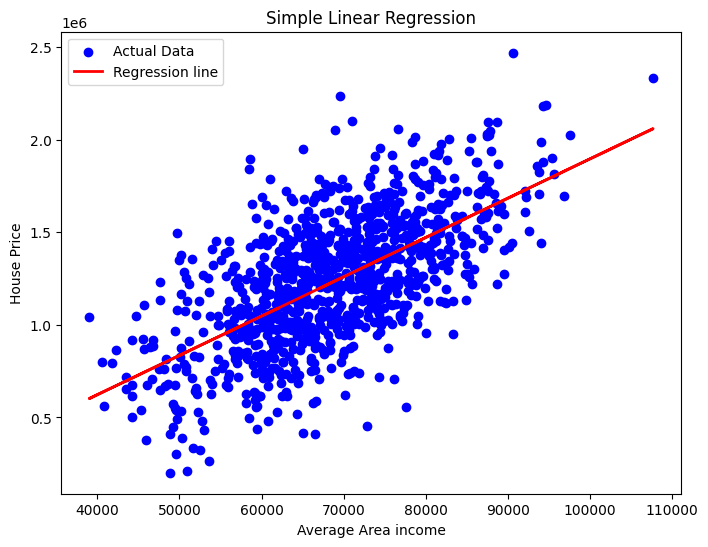

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(x_test,y_test,color='blue',label='Actual Data')
plt.plot(x_test,y_pred,color='red',linewidth=2,label='Regression line')
plt.xlabel("Average Area income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [21]:
income=float(input("Enter Average Area Income: "))
new_data=np.array([[income]])
prediction=slr_model.predict(new_data)
print("Predicted House price=${:,.2f}".format(prediction[0]))

Enter Average Area Income: 3000000
Predicted House price=$63,401,665.18


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


HyperParameter Tuning

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

In [23]:
lr=LinearRegression()

In [24]:
lr_params={
    'fit_intercept':[True,False],
    'positive':[True,False],
}


In [25]:
grid_search=GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [26]:
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring='r2')

In [27]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'fit_intercept': True, 'positive': True}


In [28]:
{'fit_intercept':True,
 'positive':False}

{'fit_intercept': True, 'positive': False}

In [29]:
print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Cross Validation Score:
0.4111086193361001


In [30]:
best_model=grid_search.best_estimator_

In [31]:
LinearRegression(
    fit_intercept=True,
    positive=False
)

LinearRegression()

In [32]:
y_pred=best_model.predict(x_test)

In [33]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 score:",r2)

MAE: 216826.35309989064
MSE: 74194887058.66
RMSE: 272387.38417676394
R2 score: 0.39694865192619766


In [34]:
print(best_model)

LinearRegression(positive=True)


In [ ]:
income=float(input("Enter Average Area Income: "))
house_age=float(input("Enter Average Area House Age: "))
rooms=float(input("Enter Average Area Number of Rooms: "))
bedrooms=float(input("Enter Average Area Number of Bedrooms: "))
population=float(input("Enter Area Population: "))
test_input=np.array([[income,house_age,rooms,bedrooms,population]])
predicted_price=model.predict(test_input)
print("\n Predicted House Price: ${:,.2f}".format(predicted_price[0]))

### Ridge Regression

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(x_train,y_train)
ridge_pred=ridge.predict(x_test)
print("Default Ridge r2:",r2_score(y_test,ridge_pred))


Default Ridge r2: 0.3969486519262033


In [36]:
param_grid={'alpha':[0.001,0.01,0.1,1,10,100]}

In [37]:
grid_ridge=GridSearchCV(estimator=Ridge(),param_grid=param_grid,scoring='r2',cv=5)

In [38]:
grid_ridge.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [39]:
print("Best Alpha :",grid_ridge.best_params_)

Best Alpha : {'alpha': 100}


In [40]:
print(grid_ridge.best_score_)

0.41110861933657433


In [41]:
best_ridge=grid_ridge.best_estimator_
ridge_pred=best_ridge.predict(x_test)

In [42]:
print("MAE: ",mean_absolute_error(y_test,ridge_pred))
print("MSE: ",mean_squared_error(y_test,ridge_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,ridge_pred)))
print("R2: ",r2_score(y_test,ridge_pred))

MAE:  216826.35310007748
MSE:  74194887058.58911
RMSE:  272387.38417663384
R2:  0.39694865192677387


### Lasso Regression

In [43]:
from sklearn.linear_model import Lasso
param_grid={'alpha':[0.001,0.01,0.1,1,10]}

In [44]:
grid_lasso=GridSearchCV(Lasso(max_iter=5000),param_grid,cv=5,scoring='r2')
grid_lasso.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=5000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, scoring='r2')

In [45]:
print(grid_lasso.best_params_)

{'alpha': 10}


In [46]:
lasso_pred=grid_lasso.predict(x_test)
print(r2_score(y_test,lasso_pred))

0.39694865193706386


In [54]:
prediction=slr_model.predict(x_test)

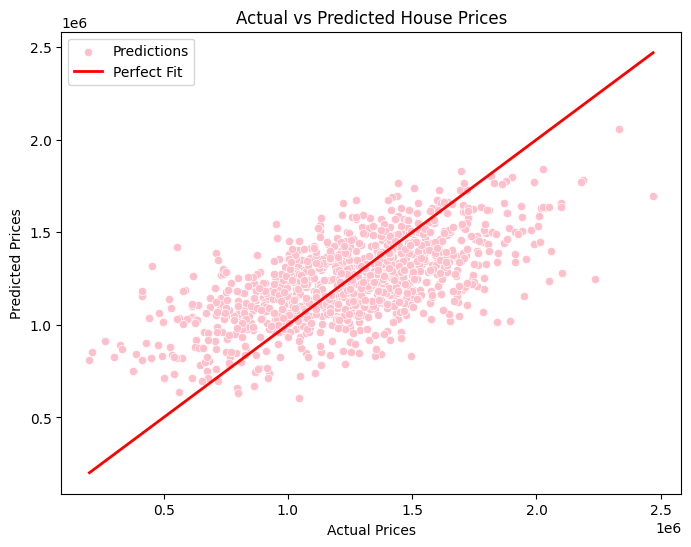

In [57]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=prediction,color='pink',label='Predictions')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red',linewidth=2,label='Perfect Fit')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()